In [7]:
from constants import *
from astropy import units as u

from phoenix_grid_creator.spectral_grid import spectral_grid
from spectrum_component_analyser.phoenix_spectrum import phoenix_spectrum

fits_file_paths = list(Path(package_path / "raw_phoenix_spectra").rglob("*.fits"))
fits_file_paths =fits_file_paths[:1]
resolution : u.Quantity[u.K] = .001*u.um
spec_grid : spectral_grid = spectral_grid.from_local_raw(fits_file_paths, resolution, False) # need to downsample resolution otherwise the spectral grid won't fit in memory...

# units are getting lost somewhere, idk why
spec_grid.Wavelengths = spec_grid.Wavelengths.to(u.um)
spec_grid.Fluxes *= u.Jy

[PHOENIX GRID CREATOR] : phoenix wavelength grid found & loaded in
[2400.] K


loading in spectra...: 100%|██████████| 1/1 [00:00<00:00, 16.34it/s]


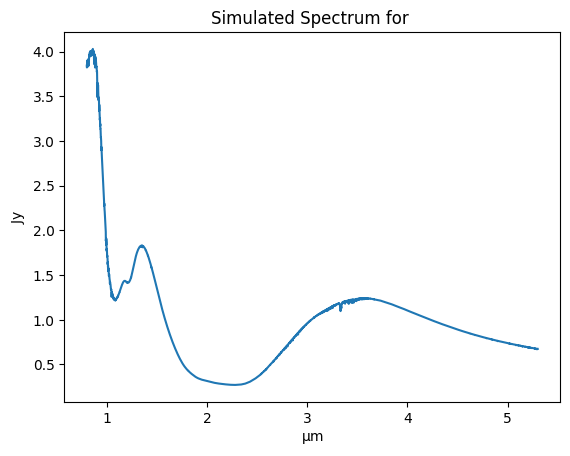

In [8]:
spec_grid.get_spectrum(spec_grid.T_effs[-1], spec_grid.FeHs[0], spec_grid.Log_gs[0]).plot()

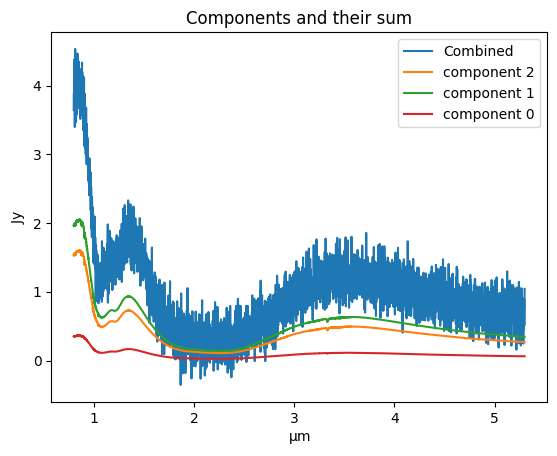

In [9]:
%matplotlib inline
# take 2 random spectra
# combine them with random weights
# see if you can reach a global minimum at a given resolution
# repeat for many resolutions

number_of_components : int = 3

from matplotlib import pyplot as plt

import rich
from spectrum_component_analyser.mcmc.simulated_spectra import get_random_simulated_spectrum
from spectrum_component_analyser.spectral_component import spectral_component
from spectrum_component_analyser.spectrum import spectrum

true_components, component_spectra, combined_spectrum = get_random_simulated_spectrum(number_of_components, spec_grid)

In [10]:


true_table = spectral_component.return_default_table()
for c in true_components:
    c.pretty_print(true_table)
rich.print(true_table)

╷          ╷          ╷          
  Weight              │ T_eff    │ [FeH]    │ log g    
╶─────────────────────┼──────────┼──────────┼─────────╴
  0.39851254974152295 │ 2400.0 K │ -4.0 dex │ 6.0 dex  
  0.5105218939600995  │ 2400.0 K │ -4.0 dex │ 6.0 dex  
  0.09096555629837755 │ 2400.0 K │ -4.0 dex │ 6.0 dex  
                      ╵          ╵          ╵

In [11]:
"""
https://www.aanda.org/articles/aa/pdf/2016/03/aa22261-13.pdf talks about a dynamical mask, could maybe introduce that?

e.g. using

total_fluxes : np.ndarray = np.zeros((len(spec_grid.Wavelengths))) * u.Jy

all_phoenix_params = list(itertools.product(spec_grid.T_effs, spec_grid.FeHs, spec_grid.Log_gs))

for t, f, l in all_phoenix_params:
    total_fluxes += spec_grid.LookupTable[t, f, l]

average_flux = total_fluxes / len(all_phoenix_params)

average_flux = average_flux[mask]
"""

import numpy as np
import scipy as sp
from spectrum_component_analyser.interpolated_spectrum import get_interpolated_phoenix_spectrum
from spectrum_component_analyser.chi_squared_minimisation import ChiHelper

number_of_parameters : int = 4 # weight, t, f, l

chi : ChiHelper = ChiHelper(
    spec_grid=spec_grid,
    number_of_components=number_of_components,
    number_of_parameters=number_of_parameters,
    observed_spectrum=combined_spectrum
)

parameter_bounds = [
        (.0, 2.),
        (np.min(spec_grid.T_effs.value), np.max(spec_grid.T_effs.value)),
        (np.min(spec_grid.FeHs.value), np.max(spec_grid.FeHs.value)),
        # (target.feh.value * .9, target.feh.value * 1.1),
        # (0, 0),
        (np.min(spec_grid.Log_gs.value), np.max(spec_grid.Log_gs.value)),
        # (target.log_g.value * .9, target.log_g.value * 1.1)
        # (1.9, 2.1),
    ]

r = chi.get_r(parameter_bounds)

print(r)

[ 9.45814764e-01  2.40000000e+03 -4.00000000e+00  6.00000000e+00
  5.08836009e-02  2.40000000e+03 -4.00000000e+00  6.00000000e+00
  1.02261713e-01  2.40000000e+03 -4.00000000e+00  6.00000000e+00] 0.010100010402502786
[ 3.15392216e-01  2.40000000e+03 -4.00000000e+00  6.00000000e+00
  5.85201816e-02  2.40000000e+03 -4.00000000e+00  6.00000000e+00
  6.37309955e-01  2.40000000e+03 -4.00000000e+00  6.00000000e+00] 0.007918114297464753
[ 1.77459866e-01  2.40000000e+03 -4.00000000e+00  6.00000000e+00
  1.86139628e-01  2.40000000e+03 -4.00000000e+00  6.00000000e+00
  6.32240663e-01  2.40000000e+03 -4.00000000e+00  6.00000000e+00] 0.005975791109588661
[ 1.77459866e-01  2.40000000e+03 -4.00000000e+00  6.00000000e+00
  1.86139628e-01  2.40000000e+03 -4.00000000e+00  6.00000000e+00
  6.32240663e-01  2.40000000e+03 -4.00000000e+00  6.00000000e+00] 0.007126844680784442
[ 1.77459866e-01  2.40000000e+03 -4.00000000e+00  6.00000000e+00
  1.86139628e-01  2.40000000e+03 -4.00000000e+00  6.00000000e+00
  

simulated / true


╷          ╷          ╷          
  Weight              │ T_eff    │ [FeH]    │ log g    
╶─────────────────────┼──────────┼──────────┼─────────╴
  0.39851254974152295 │ 2400.0 K │ -4.0 dex │ 6.0 dex  
  0.5105218939600995  │ 2400.0 K │ -4.0 dex │ 6.0 dex  
  0.09096555629837755 │ 2400.0 K │ -4.0 dex │ 6.0 dex  
                      ╵          ╵          ╵

weight 0             : 0.2532086268966104
teff 0               : 2400.0 K
feh 0                : -4.0 dex
log_g 0              : 6.0 dex


weight 1             : 0.30843014686462505
teff 1               : 2400.0 K
feh 1                : -4.0 dex
log_g 1              : 6.0 dex


weight 2             : 0.4385891185846988
teff 2               : 2400.0 K
feh 2                : -4.0 dex
log_g 2              : 6.0 dex




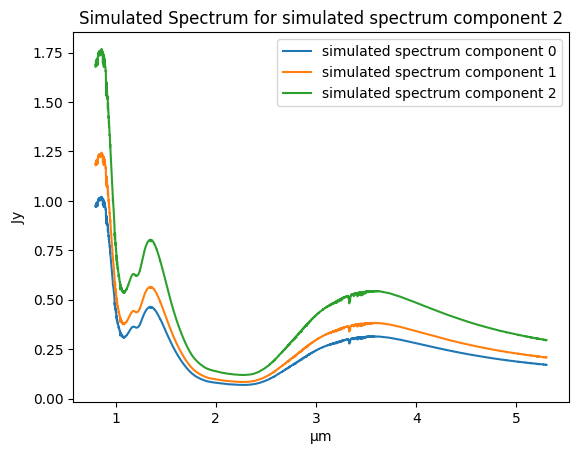

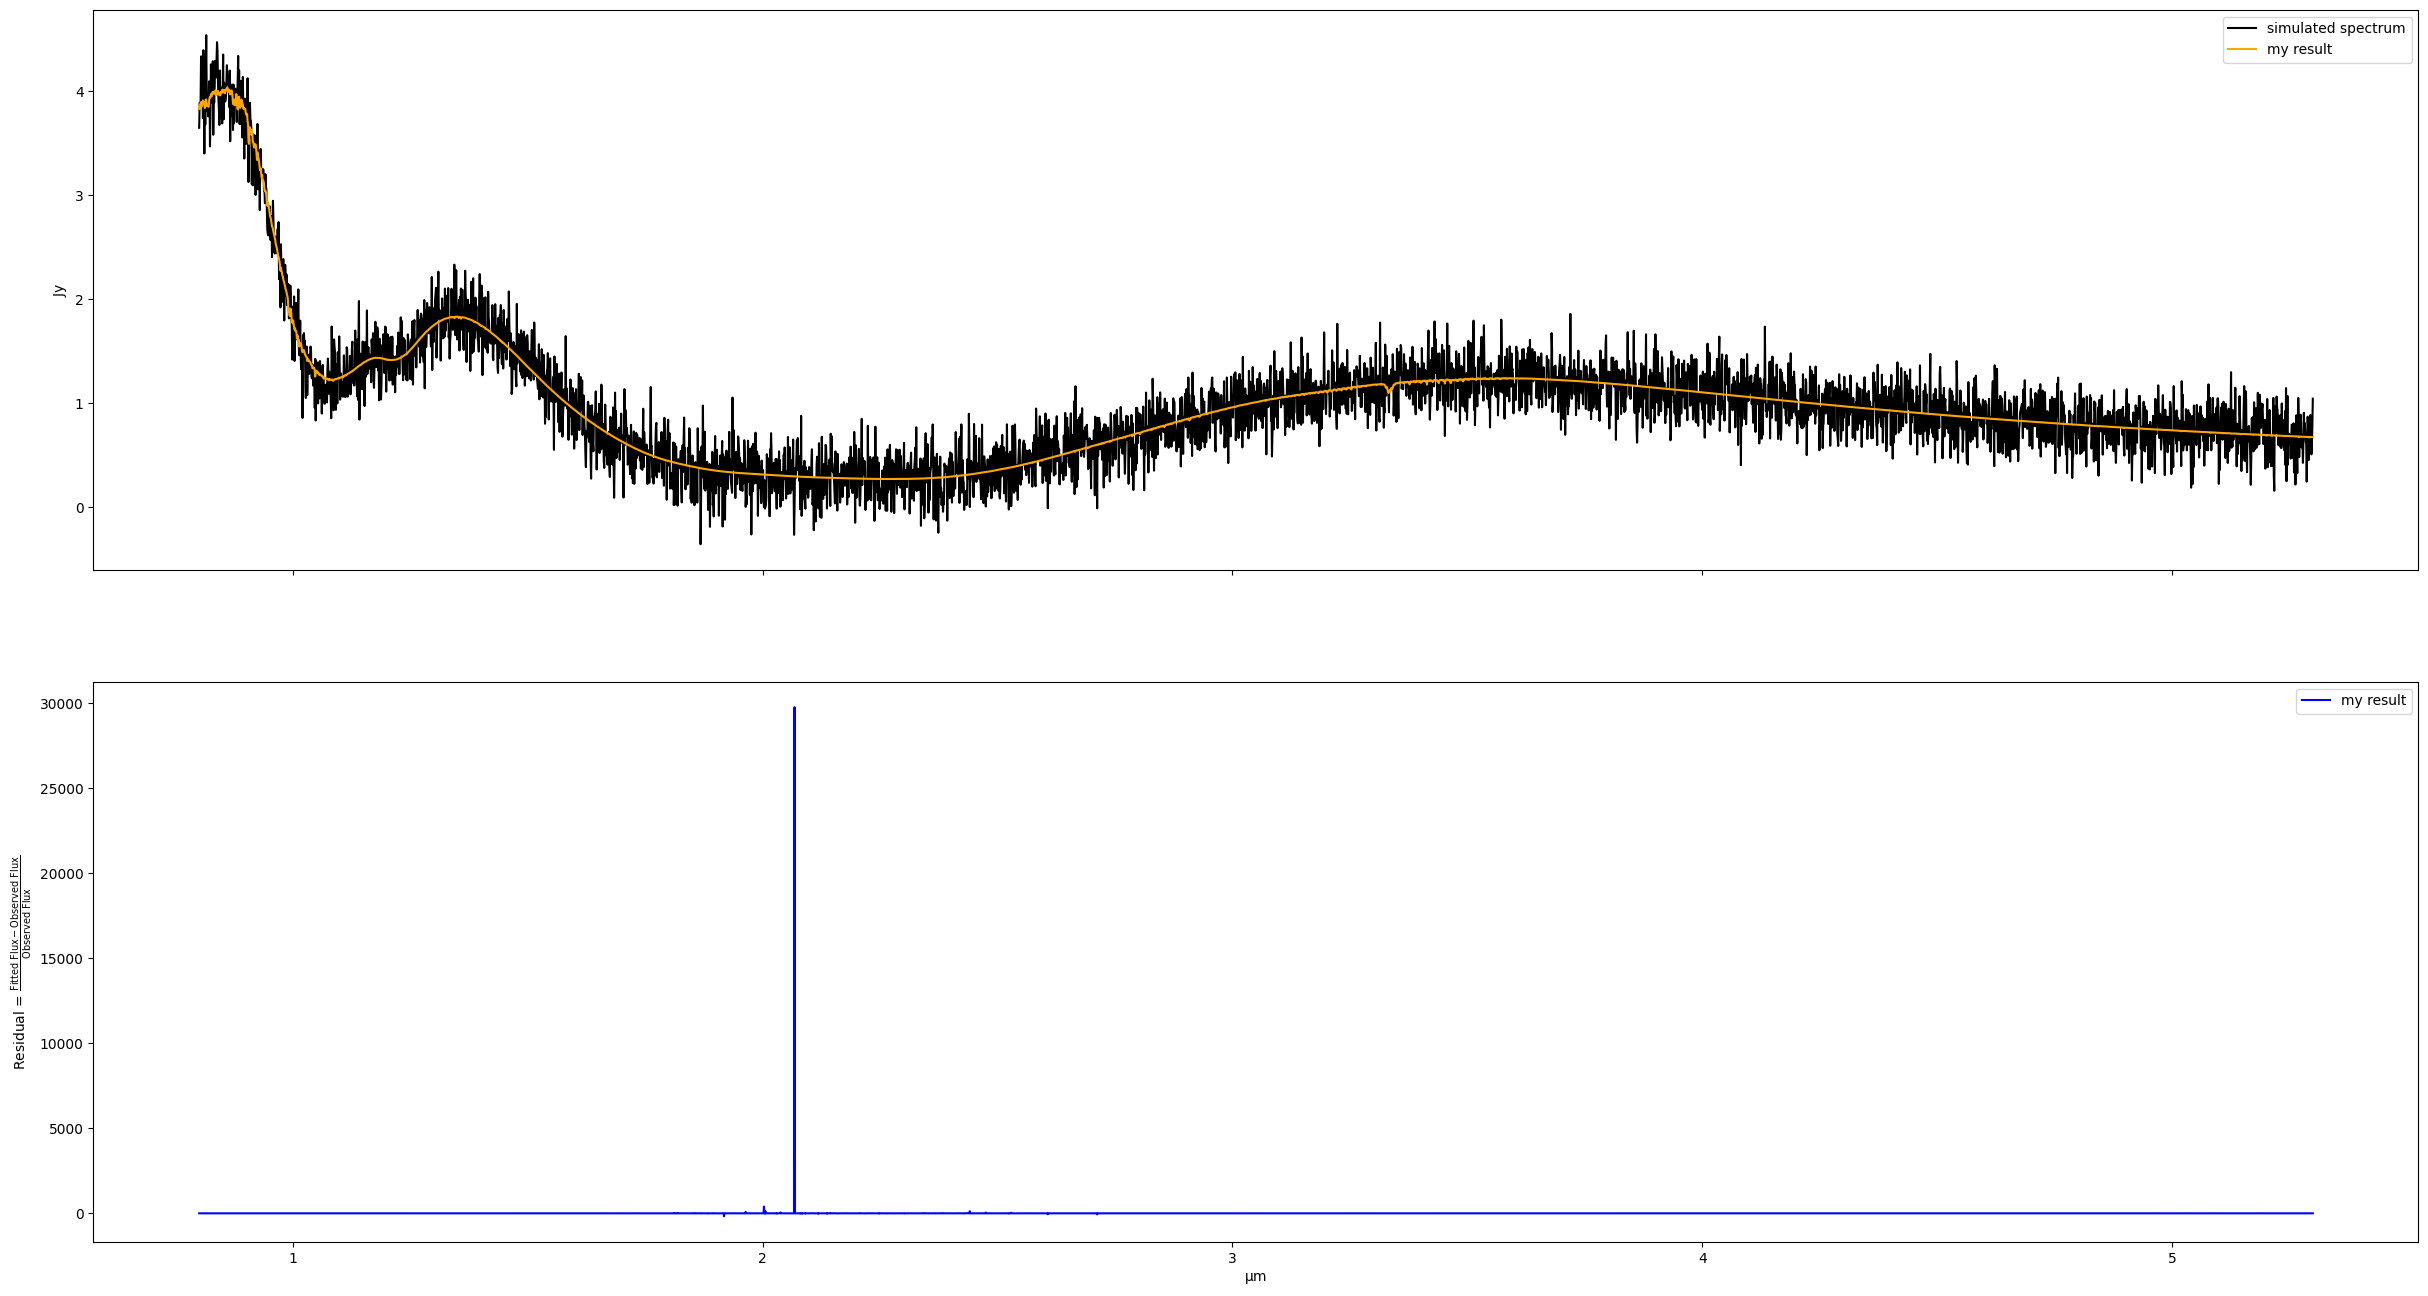

32798.614562422954


In [12]:
%matplotlib inline

print("simulated / true")
rich.print(true_table)

chi.plot(r)

In [14]:
from spectrum_component_analyser.mcmc.helper import MCMCHelper

mcmc : MCMCHelper = MCMCHelper(
    parameter_bounds=parameter_bounds,
    number_of_components=number_of_components,
    number_of_parameters=number_of_parameters,
    observed_spectrum=combined_spectrum,
    spec_grid=spec_grid,
    n_steps = 5000,
    n_walkers=64
)

sampler, samples = mcmc.run(r)


Running MCMC...


  0%|          | 0/5000 [00:00<?, ?it/s]/home/bengreen/.cache/pypoetry/virtualenvs/stellar-heterogeneity-modelling-HvrJltTr-py3.11/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 5000/5000 [00:02<00:00, 2267.19it/s]

MCMC Median Parameters: [ 4.38588549e-01  2.39999997e+03 -4.00000930e+00  6.00001861e+00
  3.08412760e-01  2.40000003e+03 -4.00001608e+00  6.00001114e+00
  2.53197710e-01  2.40000001e+03 -3.99997420e+00  6.00000516e+00]
Mean acceptance fraction: 0.000
Raw Teff1 Standard Deviation: 0.00010244027016565161


0.39851254974152295
0.5105218939600995
0.09096555629837755


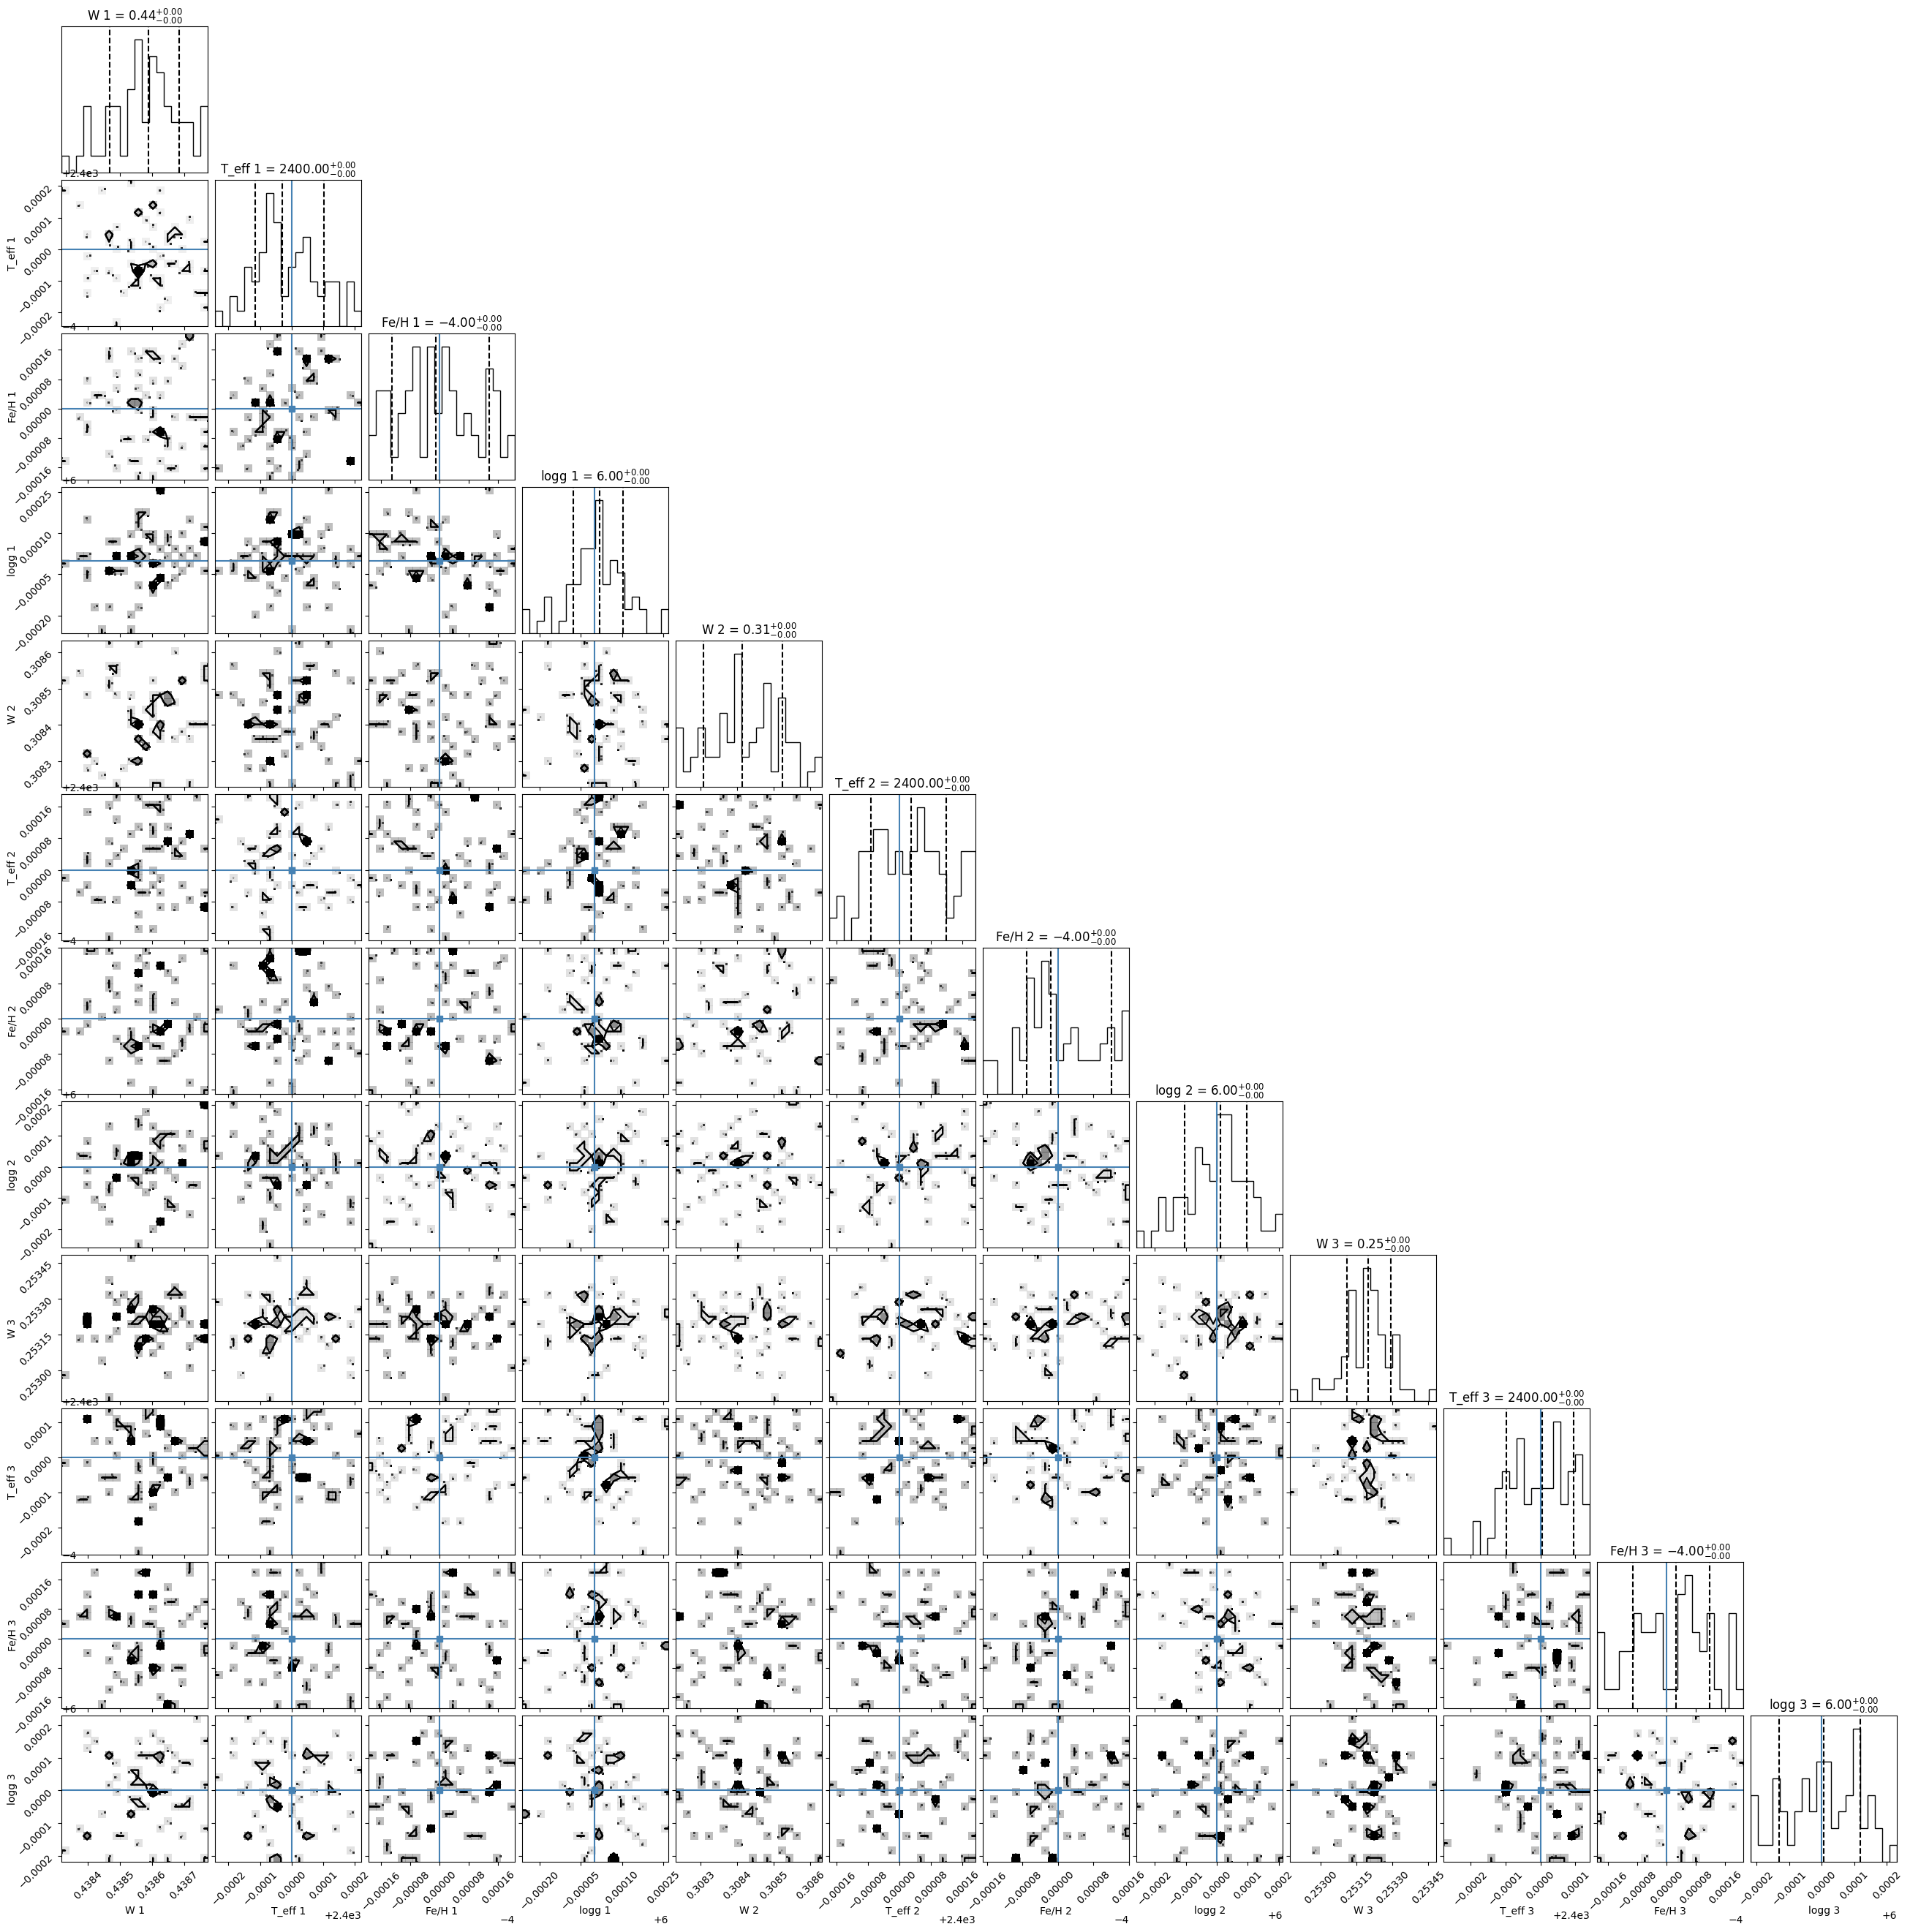

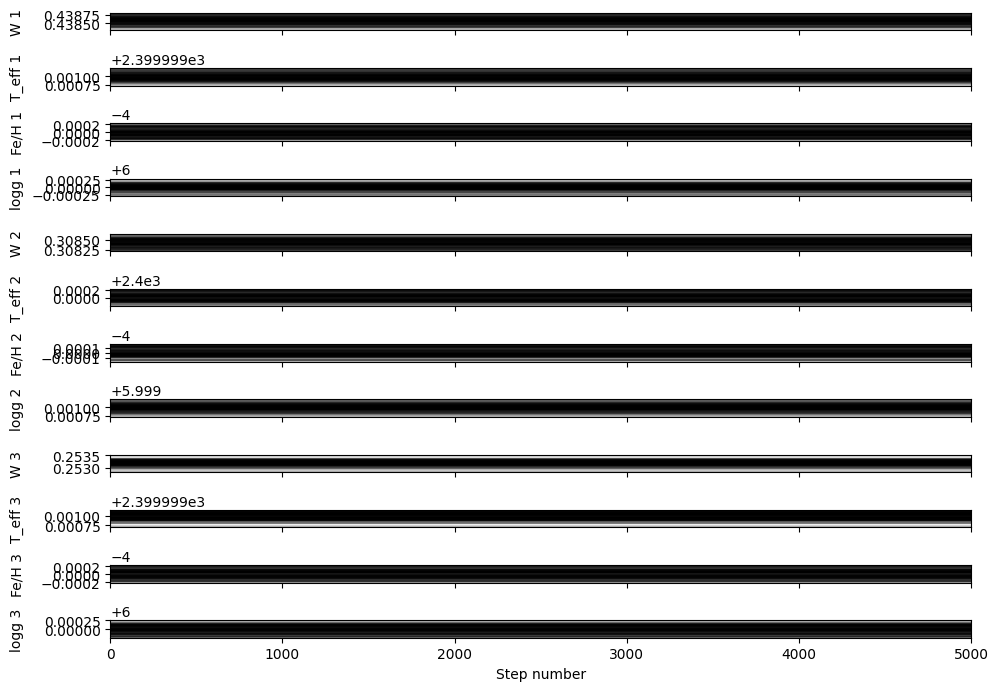

In [15]:
%matplotlib inline

mcmc.plot_corner(sampler, samples, true_components)

In [16]:
print("\n[ORIGINAL PARAMETERS]")
rich.print(true_table)

mcmc.print_parameters(samples=samples)


[ORIGINAL PARAMETERS]


╷          ╷          ╷          
  Weight              │ T_eff    │ [FeH]    │ log g    
╶─────────────────────┼──────────┼──────────┼─────────╴
  0.39851254974152295 │ 2400.0 K │ -4.0 dex │ 6.0 dex  
  0.5105218939600995  │ 2400.0 K │ -4.0 dex │ 6.0 dex  
  0.09096555629837755 │ 2400.0 K │ -4.0 dex │ 6.0 dex  
                      ╵          ╵          ╵

[np.float64(2399.999971468101), np.float64(2400.0000285501633), np.float64(2400.0000059661784)]

[MCMC RECOVERED PARAMETERS WITH 1-SIGMA ERRORS]


╷                  ╷                  ╷                  
  Weight      │ T_eff            │ [FeH]            │ log g            
╶─────────────┼──────────────────┼──────────────────┼─────────────────╴
  0.31 ± 0.00 │ 2400.00 ± 0.00 K │ -4.00 ± 0.00 dex │ 6.00 ± 0.00 dex  
  0.25 ± 0.00 │ 2400.00 ± 0.00 K │ -4.00 ± 0.00 dex │ 6.00 ± 0.00 dex  
  0.44 ± 0.00 │ 2400.00 ± 0.00 K │ -4.00 ± 0.00 dex │ 6.00 ± 0.00 dex  
              ╵                  ╵                  ╵

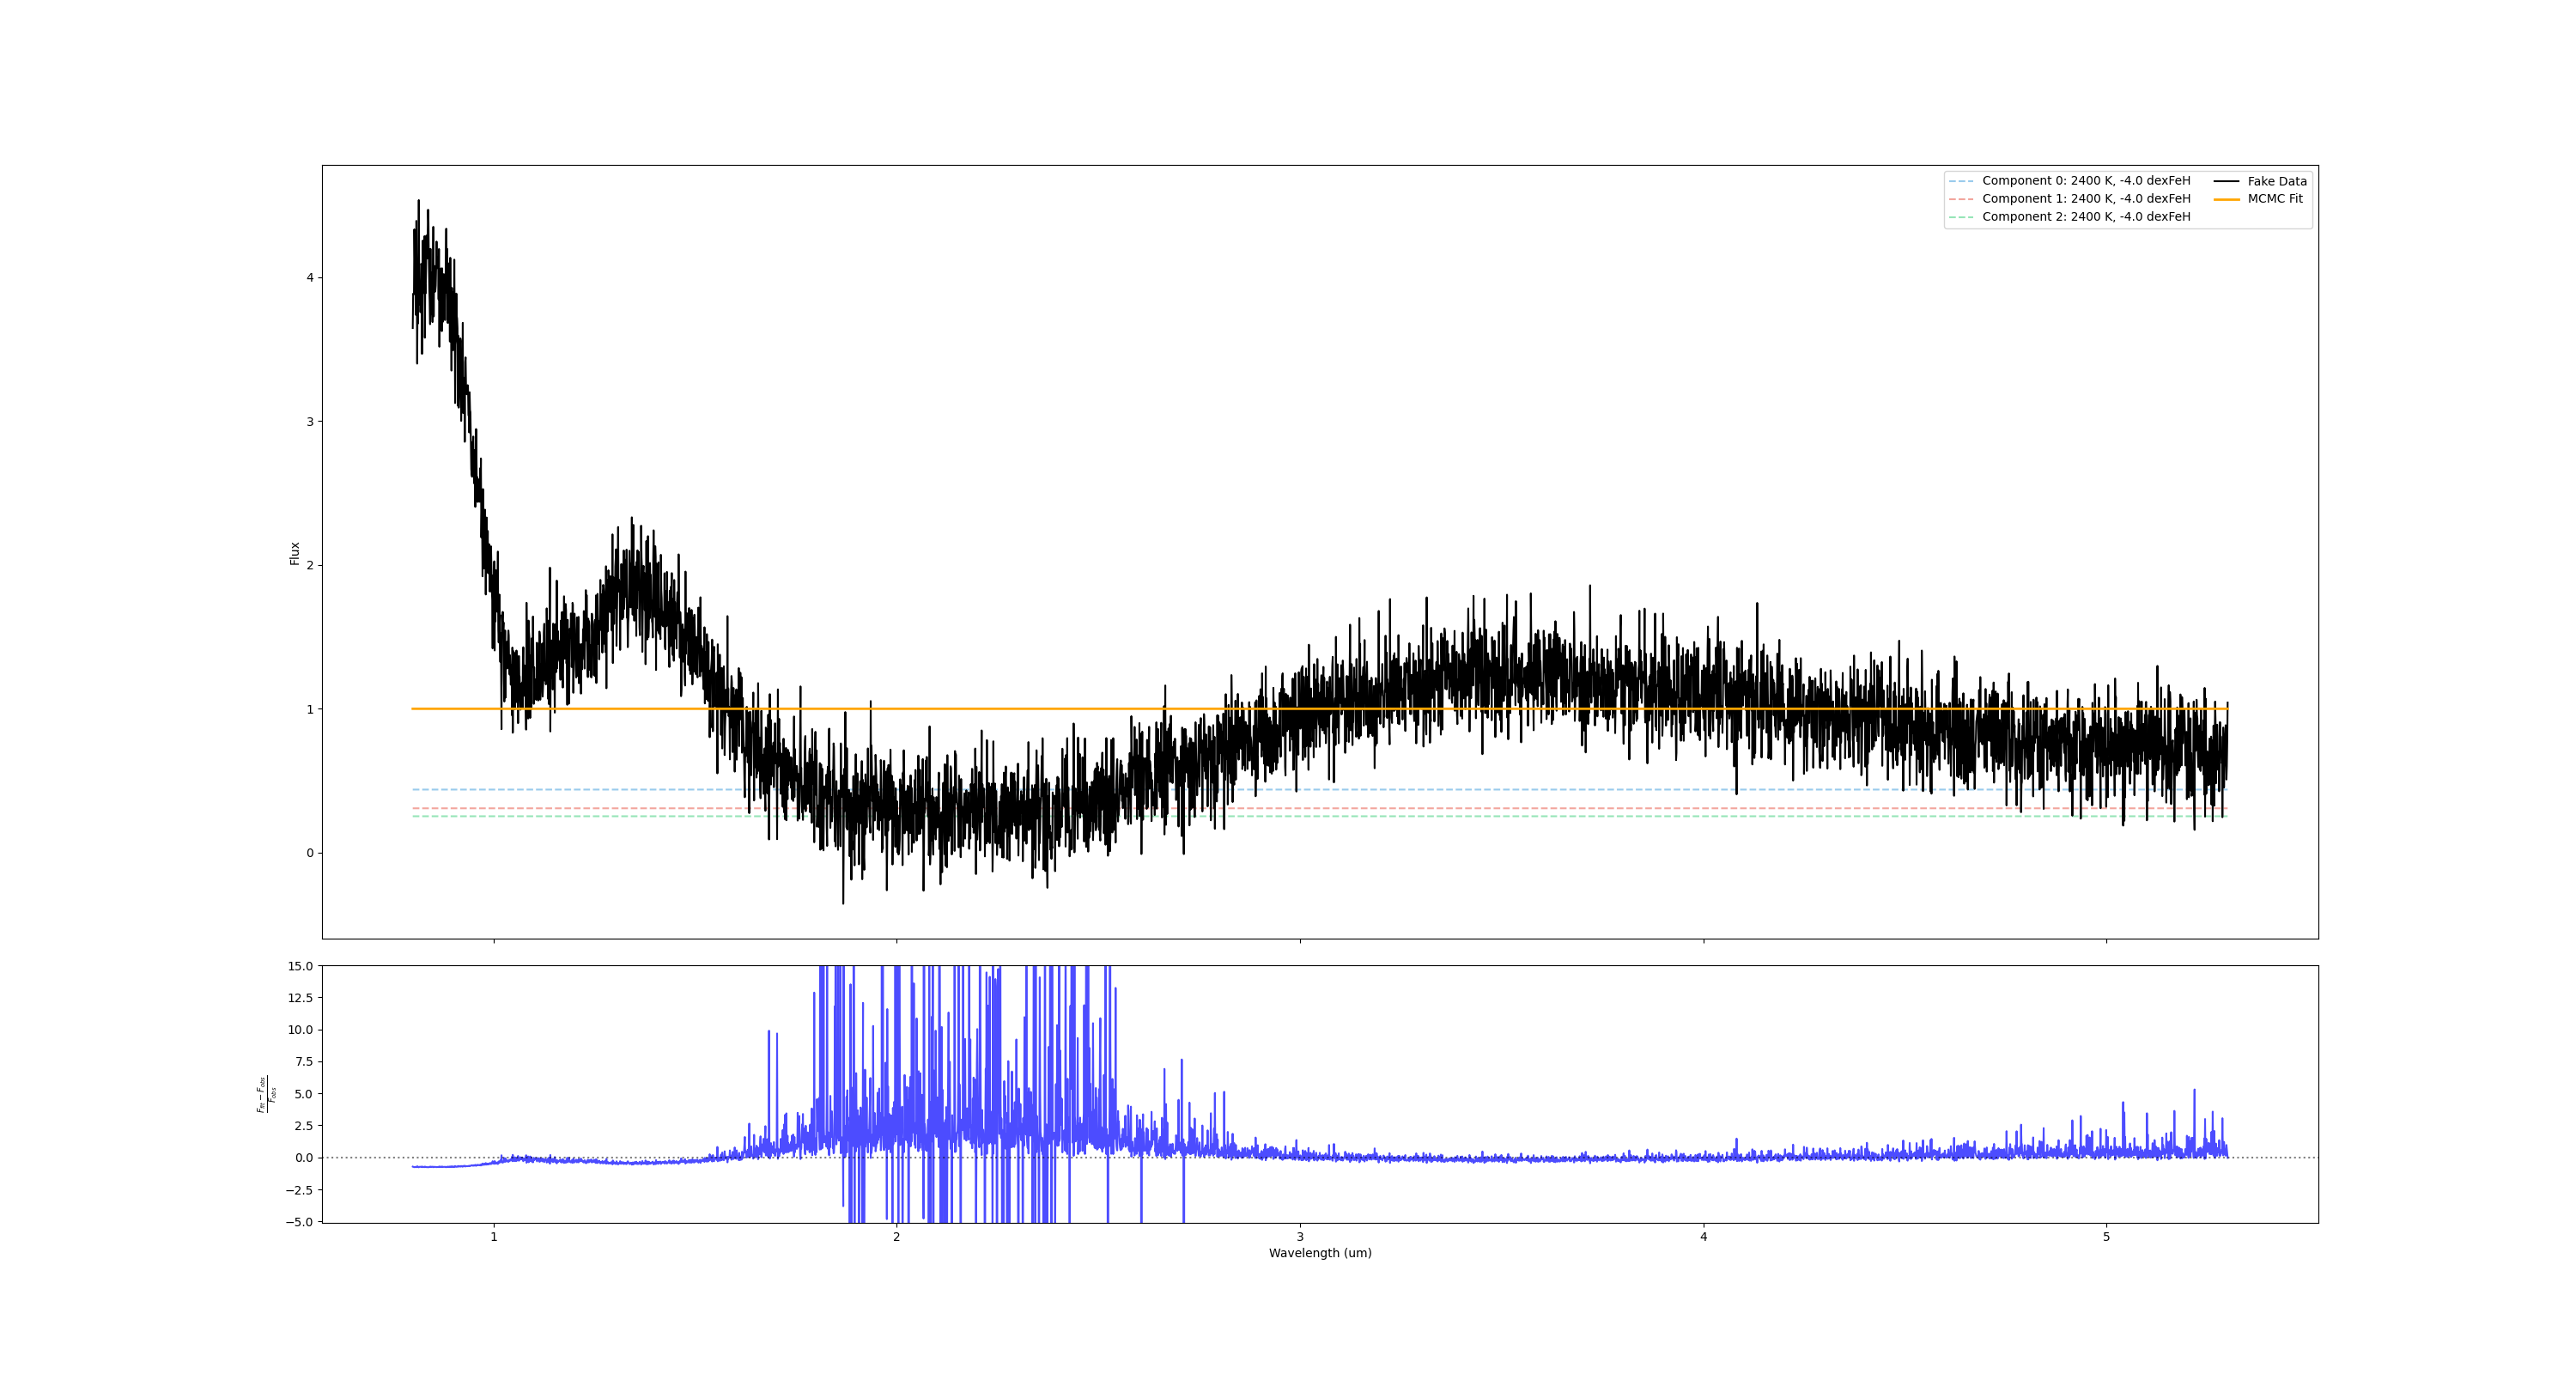

Total Absolute Residual: 109865.87538635117


In [17]:
%matplotlib widget
mcmc.plot_spectrum(samples)